EXERCICE 1

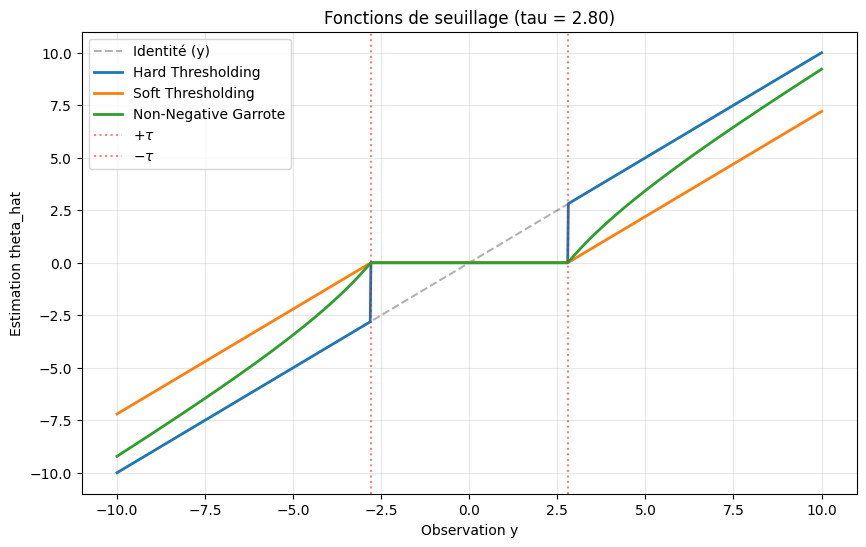

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres globaux
d = 50
beta = 0.3
tau = np.sqrt(2 * np.log(d))

def hard_thresholding(y, tau):
    """Seuillage dur (Hard)"""
    return y * (np.abs(y) > tau)

def soft_thresholding(y, tau):
    """Seuillage doux (Soft)"""
    # Formule équivalente à y * (1 - tau/|y|)+
    return np.sign(y) * np.maximum(np.abs(y) - tau, 0)

def garrote_thresholding(y, tau):
    """Non-Negative Garrote"""
    # Évite la division par zéro
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (1 - (tau**2) / (y**2))
        res = y * np.maximum(factor, 0)
    # Si y=0, le résultat doit être 0
    res[y == 0] = 0
    return res

# --- Question 1 : Tracé des fonctions ---
y_values = np.linspace(-10, 10, 1000)

plt.figure(figsize=(10, 6))
plt.plot(y_values, y_values, 'k--', alpha=0.3, label='Identité (y)')
plt.plot(y_values, hard_thresholding(y_values, tau), label='Hard Thresholding', linewidth=2)
plt.plot(y_values, soft_thresholding(y_values, tau), label='Soft Thresholding', linewidth=2)
plt.plot(y_values, garrote_thresholding(y_values, tau), label='Non-Negative Garrote', linewidth=2)

plt.axvline(x=tau, color='r', linestyle=':', alpha=0.5, label=r'$+\tau$')
plt.axvline(x=-tau, color='r', linestyle=':', alpha=0.5, label=r'$-\tau$')
plt.title(f"Fonctions de seuillage (tau = {tau:.2f})")
plt.xlabel("Observation y")
plt.ylabel("Estimation theta_hat")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

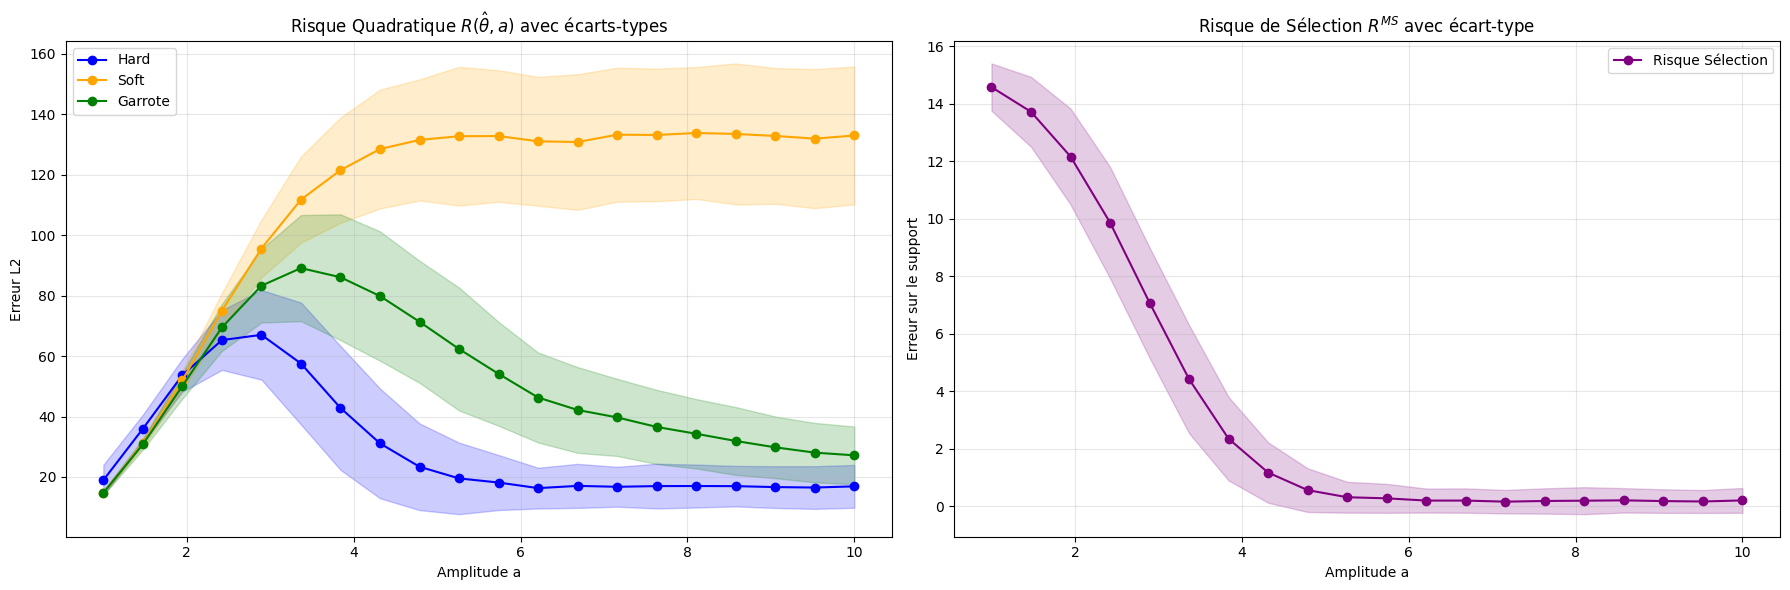

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres et Fonctions ---
d = 50
beta = 0.3
tau = np.sqrt(2 * np.log(d))

def hard_thresholding(y, tau):
    return y * (np.abs(y) > tau)

def soft_thresholding(y, tau):
    return np.sign(y) * np.maximum(np.abs(y) - tau, 0)

def garrote_thresholding(y, tau):
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (1 - (tau**2) / (y**2))
        res = y * np.maximum(factor, 0)
    res[y == 0] = 0
    return res

# --- Simulations ---
n_sim = 500  # Nombre de répétitions
a_values = np.linspace(1, 10, 20)
k = int(d**(1 - beta))

# Dictionnaires pour stocker Moyennes (mean) et Écarts-types (std)
results_L2 = {
    'Hard': {'mean': [], 'std': []},
    'Soft': {'mean': [], 'std': []},
    'Garrote': {'mean': [], 'std': []}
}

results_Sel = {'mean': [], 'std': []}

for a in a_values:
    # Stockage temporaire pour cette itération de 'a'
    temp_L2 = {'Hard': [], 'Soft': [], 'Garrote': []}
    temp_Sel = []

    for _ in range(n_sim):
        # Génération signal + bruit
        indices_support = np.random.choice(d, k, replace=False)
        eta = np.zeros(d)
        eta[indices_support] = 1
        theta_star = a * eta

        xi = np.random.randn(d)
        y = theta_star + xi

        # Calcul des estimateurs
        th_H = hard_thresholding(y, tau)
        th_S = soft_thresholding(y, tau)
        th_NG = garrote_thresholding(y, tau)

        # Risque L2
        temp_L2['Hard'].append(np.sum((th_H - theta_star)**2))
        temp_L2['Soft'].append(np.sum((th_S - theta_star)**2))
        temp_L2['Garrote'].append(np.sum((th_NG - theta_star)**2))

        # Risque de Sélection (Hard thresholding support)
        hat_eta = (np.abs(y) >= tau).astype(float)
        temp_Sel.append(np.sum(np.abs(eta - hat_eta)))

    # Calcul des statistiques (Moyenne et Ecart-type)
    for method in ['Hard', 'Soft', 'Garrote']:
        results_L2[method]['mean'].append(np.mean(temp_L2[method]))
        results_L2[method]['std'].append(np.std(temp_L2[method]))

    results_Sel['mean'].append(np.mean(temp_Sel))
    results_Sel['std'].append(np.std(temp_Sel))

# --- Conversion en array numpy pour faciliter le plotting ---
for method in results_L2:
    results_L2[method]['mean'] = np.array(results_L2[method]['mean'])
    results_L2[method]['std'] = np.array(results_L2[method]['std'])
results_Sel['mean'] = np.array(results_Sel['mean'])
results_Sel['std'] = np.array(results_Sel['std'])

# --- Graphiques avec "Nuages" (Écarts-types) ---
plt.figure(figsize=(18, 6))

# 1. Risque Quadratique
ax1 = plt.subplot(1, 2, 1)
colors = {'Hard': 'blue', 'Soft': 'orange', 'Garrote': 'green'}

for method in ['Hard', 'Soft', 'Garrote']:
    mean = results_L2[method]['mean']
    std = results_L2[method]['std']
    color = colors[method]

    # Tracé de la moyenne
    ax1.plot(a_values, mean, 'o-', label=method, color=color)
    # Tracé du "nuage" (moyenne +/- std)
    ax1.fill_between(a_values, mean - std, mean + std, color=color, alpha=0.2)

ax1.set_title("Risque Quadratique $R(\\hat{\\theta}, a)$ avec écarts-types")
ax1.set_xlabel("Amplitude a")
ax1.set_ylabel("Erreur L2")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Risque de Sélection
ax2 = plt.subplot(1, 2, 2)
mean_sel = results_Sel['mean']
std_sel = results_Sel['std']

ax2.plot(a_values, mean_sel, 'o-', color='purple', label='Risque Sélection')
# Nuage pour le risque de sélection
ax2.fill_between(a_values, mean_sel - std_sel, mean_sel + std_sel, color='purple', alpha=0.2)

ax2.set_title("Risque de Sélection $R^{MS}$ avec écart-type")
ax2.set_xlabel("Amplitude a")
ax2.set_ylabel("Erreur sur le support")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

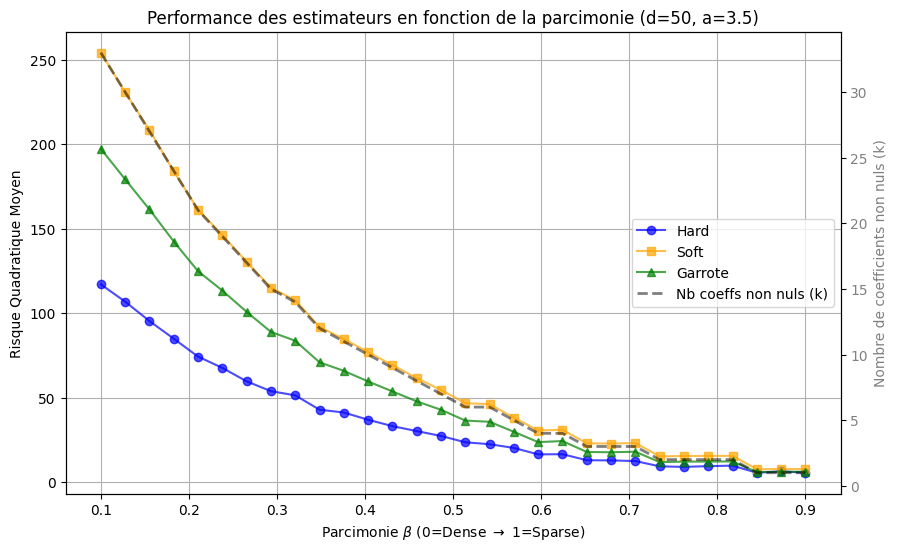

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Récupération des fonctions précédentes ---
def hard_thresholding(y, tau):
    return y * (np.abs(y) > tau)

def soft_thresholding(y, tau):
    return np.sign(y) * np.maximum(np.abs(y) - tau, 0)

def garrote_thresholding(y, tau):
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (1 - (tau**2) / (y**2))
        res = y * np.maximum(factor, 0)
    res[y == 0] = 0
    return res

# --- Paramètres de l'analyse ---
d = 50
a_fixed = 3.5  # On fixe une amplitude moyenne/forte pour bien voir les biais
beta_values = np.linspace(0.1, 0.9, 30) # Beta varie de 0.1 (dense) à 0.9 (épars)
tau = np.sqrt(2 * np.log(d))
n_sim = 1000  # Nombre de répétitions

# Stockage des résultats
risks_beta = {'Hard': [], 'Soft': [], 'Garrote': []}
nb_non_zeros = [] # Pour suivre combien de coefficients sont actifs

for beta in beta_values:
    # Nombre de coefficients non nuls pour ce beta
    k = int(d**(1 - beta))
    # On s'assure d'avoir au moins 1 coeff non nul pour l'exercice
    k = max(1, k)
    nb_non_zeros.append(k)

    temp_H, temp_S, temp_NG = [], [], []

    for _ in range(n_sim):
        # Génération du signal
        indices = np.random.choice(d, k, replace=False)
        theta_star = np.zeros(d)
        theta_star[indices] = a_fixed

        # Génération des données
        y = theta_star + np.random.randn(d)

        # Estimation
        th_H = hard_thresholding(y, tau)
        th_S = soft_thresholding(y, tau)
        th_NG = garrote_thresholding(y, tau)

        # Risque quadratique
        temp_H.append(np.sum((th_H - theta_star)**2))
        temp_S.append(np.sum((th_S - theta_star)**2))
        temp_NG.append(np.sum((th_NG - theta_star)**2))

    risks_beta['Hard'].append(np.mean(temp_H))
    risks_beta['Soft'].append(np.mean(temp_S))
    risks_beta['Garrote'].append(np.mean(temp_NG))

# --- Visualisation ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axe principal : Le Risque
line1, = ax1.plot(beta_values, risks_beta['Hard'], 'o-', label='Hard', color='blue', alpha=0.7)
line2, = ax1.plot(beta_values, risks_beta['Soft'], 's-', label='Soft', color='orange', alpha=0.7)
line3, = ax1.plot(beta_values, risks_beta['Garrote'], '^-', label='Garrote', color='green', alpha=0.7)

ax1.set_xlabel(r"Parcimonie $\beta$ (0=Dense $\to$ 1=Sparse)")
ax1.set_ylabel("Risque Quadratique Moyen")
ax1.set_title(f"Performance des estimateurs en fonction de la parcimonie (d={d}, a={a_fixed})")
ax1.grid(True)

# Axe secondaire : Nombre de variables actives
ax2 = ax1.twinx()
line4, = ax2.plot(beta_values, nb_non_zeros, 'k--', linewidth=2, alpha = 0.5, label='Nb coeffs non nuls (k)')
ax2.set_ylabel("Nombre de coefficients non nuls (k)", color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Légende combinée
lines = [line1, line2, line3, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.show()

EXERCICE 2

Seuil de détection sur les différences : 0.5580
----------------------------------------
Indices détectés (Mathématiques) : [10 30 40]
Vrais indices (Mathématiques)    : [10, 30, 40]
----------------------------------------


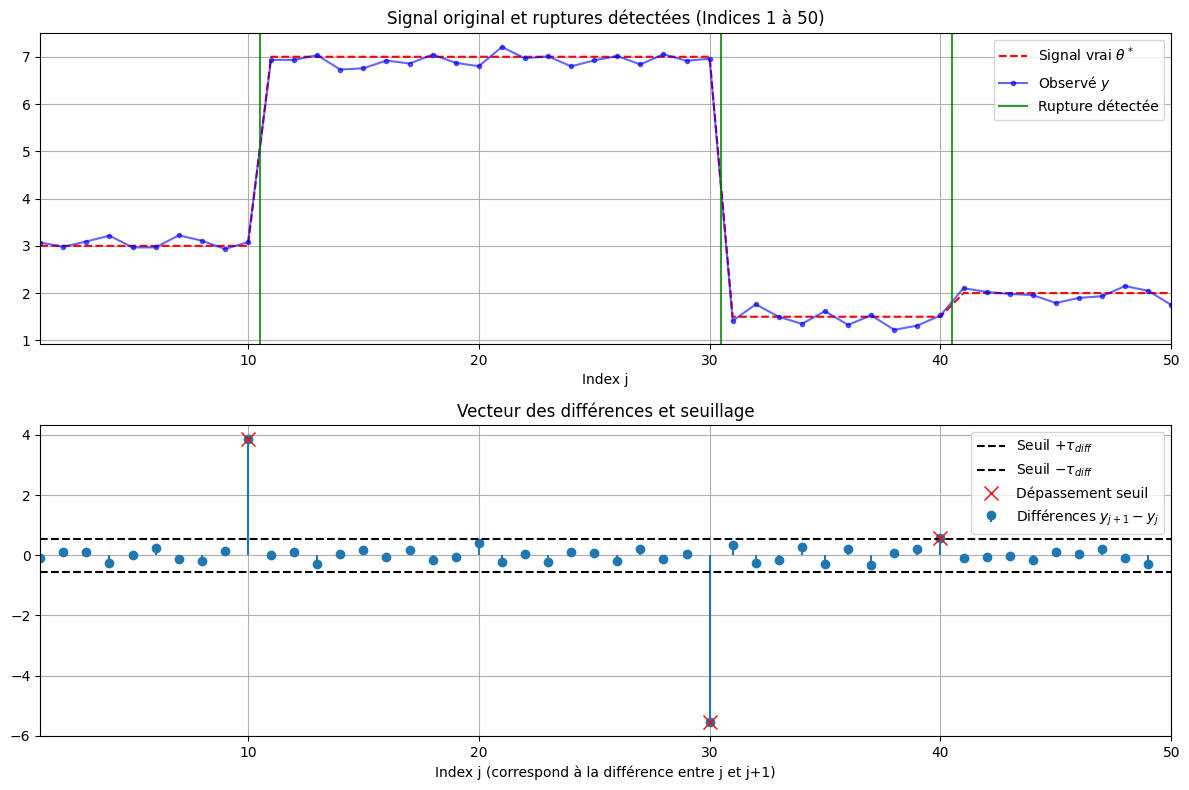

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- EXERCICE 2 (Version Indices Mathématiques) ---

# 1. Construction du signal vrai theta*
d = 50
theta_star = np.zeros(d)
theta_star[0:10] = 3
theta_star[10:30] = 7
theta_star[30:40] = 1.5
theta_star[40:] = 2

# Ruptures théoriques (Indices Mathématiques j où theta change entre j et j+1)
true_jumps_math = [10, 30, 40]

# 2. Génération des observations
epsilon = 1 / np.sqrt(d)
np.random.seed(42)
xi = np.random.randn(d)
y = theta_star + epsilon * xi

# 3. Méthode de détection par différences
diff_y = np.diff(y)

# Calcul du seuil adapté
sigma_diff = epsilon * np.sqrt(2)
tau_diff = sigma_diff * np.sqrt(2 * np.log(d - 1))

# Estimation des ruptures
# Indices Python trouvés
detected_indices_python = np.where(np.abs(diff_y) > tau_diff)[0]

# CONVERSION : On ajoute +1 pour obtenir les indices mathématiques
detected_jumps_math = detected_indices_python + 1

print(f"Seuil de détection sur les différences : {tau_diff:.4f}")
print("-" * 40)
print(f"Indices détectés (Mathématiques) : {detected_jumps_math}")
print(f"Vrais indices (Mathématiques)    : {true_jumps_math}")
print("-" * 40)

# 4. Visualisation
plt.figure(figsize=(12, 8))
# Création d'un axe X mathématique qui va de 1 à 50
x_axis = np.arange(1, d + 1)

# --- Graphique du signal ---
plt.subplot(2, 1, 1)
plt.plot(x_axis, theta_star, 'r--', label=r'Signal vrai $\theta^*$')
plt.plot(x_axis, y, 'b.-', alpha=0.6, label=r'Observé $y$')

# Marquer les ruptures détectées (Positionnées entre j et j+1, donc à j + 0.5)
for jump in detected_jumps_math:
    plt.axvline(x=jump + 0.5, color='g', linestyle='-', alpha=0.8,
                label='Rupture détectée' if jump == detected_jumps_math[0] else "")

plt.title("Signal original et ruptures détectées (Indices 1 à 50)")
plt.xlabel("Index j")
plt.xlim(1, d) # On force l'affichage de 1 à 50
plt.legend()
plt.grid(True)

# --- Graphique des différences ---
plt.subplot(2, 1, 2)
# L'axe des différences va de 1 à 49 (puisqu'il y a d-1 différences)
x_diff = np.arange(1, d)
plt.stem(x_diff, diff_y, basefmt=" ", label=r'Différences $y_{j+1}-y_j$')

plt.axhline(y=tau_diff, color='k', linestyle='--', label=r'Seuil $+\tau_{diff}$')
plt.axhline(y=-tau_diff, color='k', linestyle='--', label=r'Seuil $-\tau_{diff}$')

# Mettre en évidence les points dépassant le seuil
# Attention : pour le plot, on utilise les indices mathématiques comme coordonnées X
plt.plot(detected_jumps_math, diff_y[detected_indices_python], 'rx', markersize=10, label='Dépassement seuil')

plt.title("Vecteur des différences et seuillage")
plt.xlabel("Index j (correspond à la différence entre j et j+1)")
plt.xlim(1, d)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

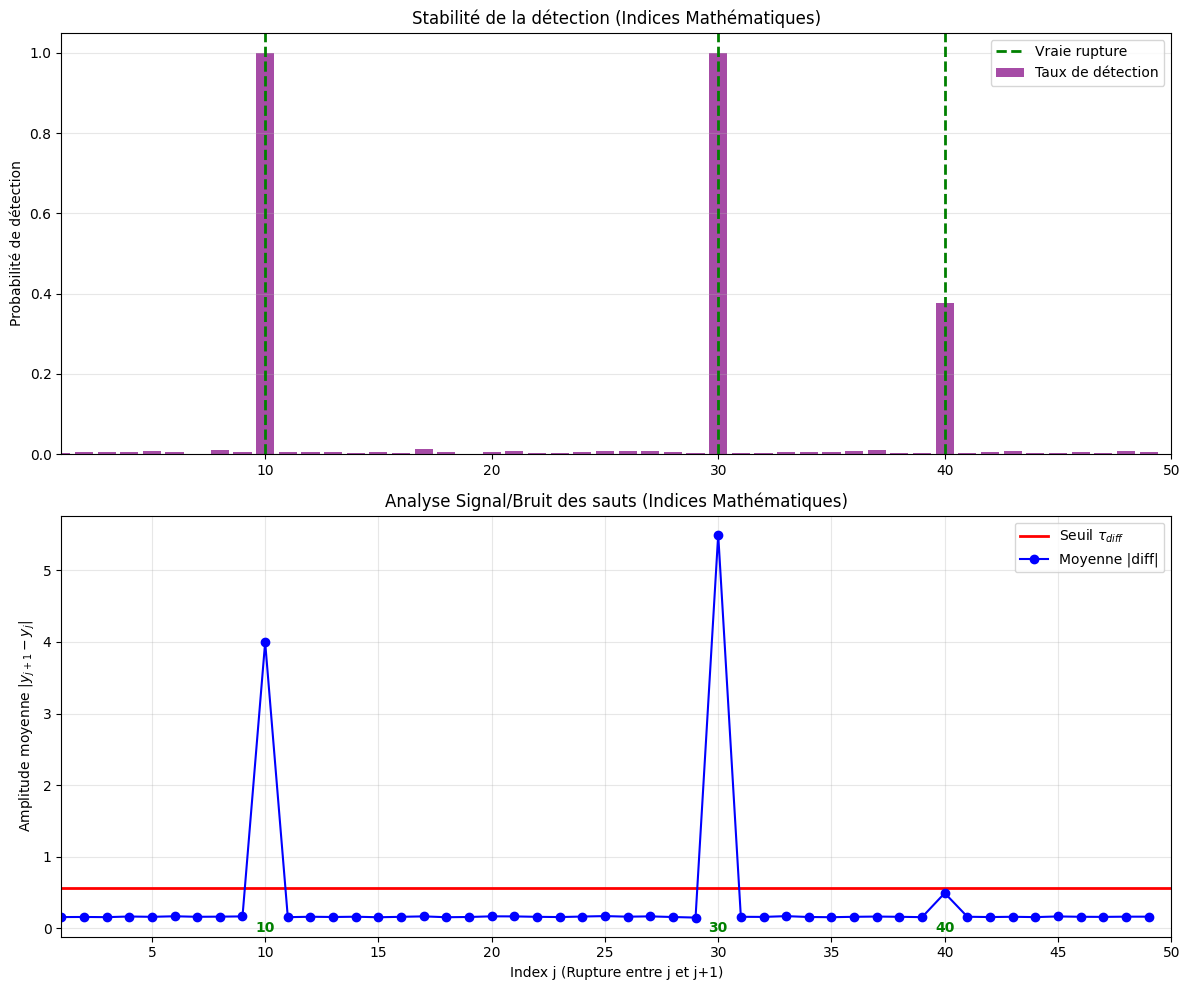

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- EXERCICE 2 : Variabilité (Indices Mathématiques) ---

# 1. Paramètres et Signal Vrai
d = 50
n_sim = 1000  # Nombre de répétitions pour la simulation
theta_star = np.zeros(d)
theta_star[0:10] = 3
theta_star[10:30] = 7
theta_star[30:40] = 1.5
theta_star[40:] = 2

# Ruptures théoriques (Mathématiques : 1-based)
true_jumps_math = [10, 30, 40]

# Calcul du seuil théorique (constant pour toutes les simus)
epsilon = 1 / np.sqrt(d)
sigma_diff = epsilon * np.sqrt(2)
tau_diff = sigma_diff * np.sqrt(2 * np.log(d - 1))

# 2. Boucle de Simulation (Monte Carlo)
# On stocke les résultats de chaque simulation
detection_counts = np.zeros(d - 1) # Compteur de détections par index
all_abs_diffs = np.zeros((n_sim, d - 1)) # Stockage des différences absolues

np.random.seed(42)

for i in range(n_sim):
    # Génération du bruit
    xi = np.random.randn(d)
    y = theta_star + epsilon * xi

    # Calcul des différences
    diff_y = np.diff(y)
    abs_diff = np.abs(diff_y)

    # Stockage pour le "nuage"
    all_abs_diffs[i, :] = abs_diff

    # Détection (1 si dépassement, 0 sinon)
    detected_mask = (abs_diff > tau_diff).astype(float)
    detection_counts += detected_mask

# 3. Calcul des Statistiques
# Fréquence de détection (Probabilité)
detection_freq = detection_counts / n_sim

# Moyenne et Ecart-type des différences (pour le nuage)
mean_diff = np.mean(all_abs_diffs, axis=0)
std_diff = np.std(all_abs_diffs, axis=0)

# 4. Visualisation (Axes Mathématiques)
plt.figure(figsize=(12, 10))

# Axe X mathématique pour les différences : de 1 à 49
# (Car la différence i est entre l'élément i et i+1)
x_axis_math = np.arange(1, d)

# --- Graphique 1 : Histogramme de Probabilité de Détection ---
plt.subplot(2, 1, 1)
plt.bar(x_axis_math, detection_freq, color='purple', alpha=0.7, label='Taux de détection')

# Marquage des vraies ruptures
for jump in true_jumps_math:
    plt.axvline(x=jump, color='green', linestyle='--', linewidth=2,
                label='Vraie rupture' if jump == true_jumps_math[0] else "")

plt.title("Stabilité de la détection (Indices Mathématiques)")
plt.ylabel("Probabilité de détection")
plt.xlim(1, d)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# --- Graphique 2 : Force du Signal et Nuage d'Incertitude ---
plt.subplot(2, 1, 2)

# Le seuil
plt.axhline(y=tau_diff, color='red', linewidth=2, label=r'Seuil $\tau_{diff}$')

# La moyenne des différences
plt.plot(x_axis_math, mean_diff, 'o-', color='blue', label='Moyenne |diff|')

# Le "Nuage" (Zone d'incertitude)
#plt.fill_between(x_axis_math,
#                 np.maximum(0, mean_diff - std_diff),
#                 mean_diff + std_diff,
#                 color='blue', alpha=0.2, label='Écart-type (Nuage)')

# Marquage des vraies ruptures sur l'axe X
plt.xticks(np.arange(0, 51, 5)) # Graduation propre
for jump in true_jumps_math:
    plt.text(jump, -0.05, str(jump), color='green', fontweight='bold', ha='center')

plt.title("Analyse Signal/Bruit des sauts (Indices Mathématiques)")
plt.xlabel("Index j (Rupture entre j et j+1)")
plt.ylabel("Amplitude moyenne $|y_{j+1} - y_j|$")
plt.xlim(1, d)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Code que Charles m'a donne qui est censé etre le bon avec le seuil du prof

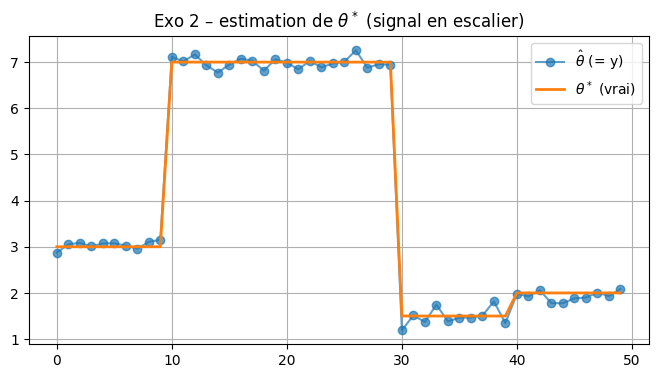

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 800x300 with 0 Axes>

In [ ]:
# ===== Exercice 2 : Détection de ruptures =====

# 1) paramètres du modèle
eps = 1 / np.sqrt(d)   # ε = 1/√d

# 2) signal vrai
theta_star = np.zeros(d)
theta_star[0:10]  = 3
theta_star[10:30] = 7
theta_star[30:40] = 1.5
theta_star[40: ]  = 2

# 3) observations
xi = np.random.normal(0, 1, d)
y = theta_star + eps * xi

# --- affichage du signal ---
plt.figure(figsize=(8, 4))
plt.plot(y, marker="o", label=r"$\hat{\theta}$ (= y)", alpha=0.7)
plt.plot(theta_star, label=r"$\theta^*$ (vrai)", linewidth=2)
plt.title("Exo 2 – estimation de $\\theta^*$ (signal en escalier)")
plt.legend()
plt.grid(True)
plt.show()

# 4) estimation de Δ*
delta_hat = y[1:] - y[:-1]          # taille d-1

# seuil : 2 * sqrt(ln(d) / d)
seuil_delta = 2 * np.sqrt(np.log(d) / d)

# indices (0..d-2) pour le stem
j = np.arange(d - 1)

plt.figure(figsize=(8, 3))
# stem des deltas
plt.stem(j, delta_hat, use_line_collection=True)

# lignes de seuil
plt.axhline(seuil_delta,  color="red", linestyle="--", label=r"seuil $2\sqrt{\ln(d)/d}$")
plt.axhline(-seuil_delta, color="red", linestyle="--")
plt.axhline(0, color="black", linewidth=1)

# points qui dépassent le seuil
sel = np.abs(delta_hat) > seuil_delta
plt.scatter(j[sel], delta_hat[sel], color="red", zorder=3, label="Δ̂ au-dessus du seuil")

plt.title(r"Exo 2 – $\hat\Delta_j = y_{j+1} - y_j$ avec seuil et points sélectionnés")
plt.legend()
plt.grid(True)
plt.show()

EXERCICE3

Données chargées : 100 années d'observations (1871-1970).
Estimation du bruit (écart-type) : 115.32
Seuil de détection : 349.97
Années de rupture détectées : [1877 1887 1913 1915]


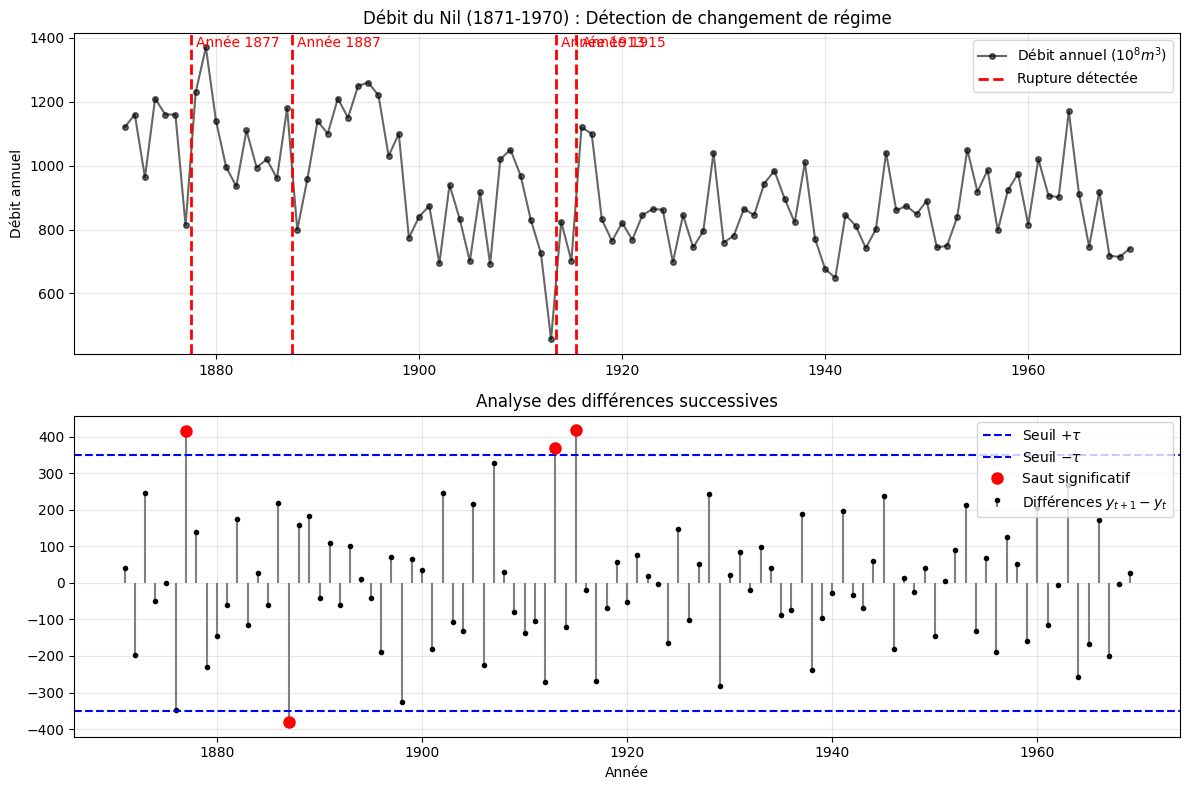

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Chargement des données réelles ---
# URL stable vers le dataset "Nile" (hébergé sur GitHub)
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/Nile.csv"

try:
    df = pd.read_csv(url)
    # Les données sont dans la colonne 'value', les années dans 'time'
    y_real = df['value'].values
    years = df['time'].values
    d = len(y_real)
    print(f"Données chargées : {d} années d'observations (1871-1970).")

except Exception as e:
    print("Erreur de chargement. Vérifiez votre connexion internet.")
    # Fallback si pas d'internet : données synthétiques imitant le Nil
    d = 100
    years = np.arange(1871, 1971)
    y_real = np.concatenate([np.random.normal(1100, 100, 28), np.random.normal(850, 100, 72)])

# --- 2. Application de la méthode de l'Exercice 2 ---

# A. Calcul des différences (y_{j+1} - y_j)
diff_y = np.diff(y_real)

# B. Estimation du niveau de bruit (Sigma)
# Sur des données réelles, on ne connait pas epsilon.
# On l'estime via la MAD (Median Absolute Deviation) pour être robuste aux sauts.
median_abs_diff = np.median(np.abs(diff_y - np.median(diff_y)))
sigma_hat = median_abs_diff / (0.6745 * np.sqrt(2))

print(f"Estimation du bruit (écart-type) : {sigma_hat:.2f}")

# C. Calcul du seuil universel
# Formule : sigma * sqrt(2 * log(d)
tau = sigma_hat * np.sqrt(2 * np.log(d))
print(f"Seuil de détection : {tau:.2f}")

# D. Détection des ruptures
# On cherche où la différence absolue dépasse le seuil
jumps_indices = np.where(np.abs(diff_y) > tau)[0]

# Récupération des années correspondantes aux ruptures
rupture_years = years[jumps_indices]
print(f"Années de rupture détectées : {rupture_years}")

# --- 3. Visualisation ---
plt.figure(figsize=(12, 8))

# Graphique du haut : Série temporelle
plt.subplot(2, 1, 1)
plt.plot(years, y_real, 'o-', color='black', alpha=0.6, markersize=4, label='Débit annuel ($10^8 m^3$)')

# Affichage de la rupture détectée
for k, jump_idx in enumerate(jumps_indices):
    # Le saut se produit entre l'année j et j+1. On trace une ligne verticale.
    rupture_year = years[jump_idx]
    plt.axvline(x=rupture_year + 0.5, color='red', linestyle='--', linewidth=2,
                label='Rupture détectée' if k == 0 else "")

    # Annotation
    plt.text(rupture_year + 1, np.max(y_real), f"Année {int(rupture_year)}", color='red')

plt.title("Débit du Nil (1871-1970) : Détection de changement de régime")
plt.ylabel("Débit annuel")
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique du bas : Vecteur des différences
plt.subplot(2, 1, 2)
plt.stem(years[:-1], diff_y, basefmt=" ", linefmt='gray', markerfmt='k.', label='Différences $y_{t+1}-y_t$')

# Seuils
plt.axhline(y=tau, color='blue', linestyle='--', label=r'Seuil $+\tau$')
plt.axhline(y=-tau, color='blue', linestyle='--', label=r'Seuil $-\tau$')

# Mise en valeur du dépassement
plt.plot(years[jumps_indices], diff_y[jumps_indices], 'ro', markersize=8, label='Saut significatif')

plt.xlabel("Année")
plt.title("Analyse des différences successives")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Données chargées : 100 années d'observations (1871-1970).
Bruit estimé (sigma): 115.32
Seuil utilisé (tau): 349.9722207440003


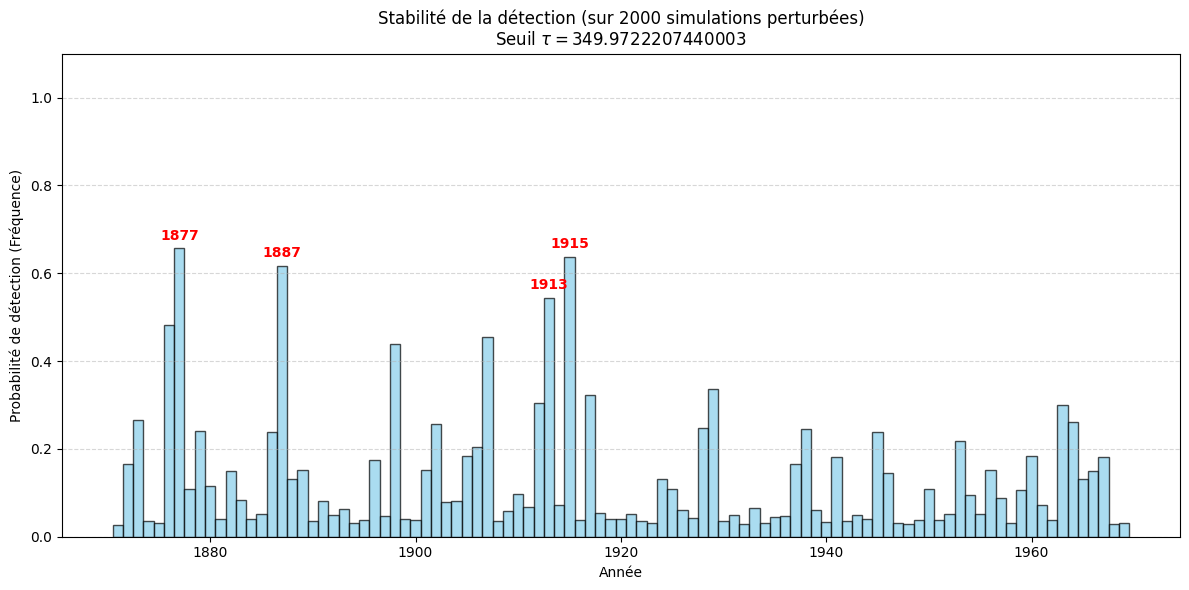

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Chargement des données réelles ---
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/Nile.csv"

try:
    df = pd.read_csv(url)
    y_real = df['value'].values
    years = df['time'].values
    d = len(y_real)
    print(f"Données chargées : {d} années d'observations (1871-1970).")
except Exception as e:
    print("Erreur de chargement. Mode fallback.")
    d = 100
    years = np.arange(1871, 1971)
    y_real = np.concatenate([np.random.normal(1100, 100, 28), np.random.normal(850, 100, 72)])

# --- 2. Paramétrage initial (Votre méthode) ---
diff_y = np.diff(y_real)

# Estimation du bruit (MAD)
median_abs_diff = np.median(np.abs(diff_y - np.median(diff_y)))
sigma_hat = median_abs_diff / (0.6745 * np.sqrt(2))

# Seuil (fixé à 340 comme dans votre exemple, ou calculé)
tau = sigma_hat * np.sqrt(2 * np.log(d))

print(f"Bruit estimé (sigma): {sigma_hat:.2f}")
print(f"Seuil utilisé (tau): {tau}")

# --- 3. Analyse de Stabilité (Monte Carlo) ---
# Nombre de simulations pour calculer la probabilité
n_simulations = 2000
detection_counts = np.zeros(len(years) - 1)

np.random.seed(42) # Pour la reproductibilité

for i in range(n_simulations):
    # On ajoute un bruit gaussien au signal d'origine pour tester la robustesse
    # On utilise sigma_hat comme magnitude du bruit perturbateur
    noise = np.random.normal(0, sigma_hat, size=len(y_real))

    # Signal perturbé
    y_simulated = y_real + noise

    # Application de la détection
    diff_sim = np.diff(y_simulated)

    # On repère les indices où la différence dépasse le seuil
    detected_indices = np.where(np.abs(diff_sim) > tau)[0]

    # On incrémente le compteur pour ces années là
    detection_counts[detected_indices] += 1

# Conversion en probabilité (0 à 1)
detection_probs = detection_counts / n_simulations

# --- 4. Visualisation de la stabilité ---
plt.figure(figsize=(12, 6))

# Création du bar plot
# years[:-1] car diff_y a une longueur de d-1
plt.bar(years[:-1], detection_probs, width=1.0, color='skyblue', edgecolor='black', alpha=0.7)

# Mise en forme
plt.title(f"Stabilité de la détection (sur {n_simulations} simulations perturbées)\nSeuil $\\tau={tau}$")
plt.xlabel("Année")
plt.ylabel("Probabilité de détection (Fréquence)")
plt.ylim(0, 1.1) # Pour laisser un peu d'espace au dessus de 1.0
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajout d'une ligne rouge pour mettre en évidence les probabilités fortes (> 50%)
strong_detection_indices = np.where(detection_probs > 0.5)[0]
for idx in strong_detection_indices:
    year_val = years[idx]
    prob_val = detection_probs[idx]
    plt.text(year_val, prob_val + 0.02, f"{int(year_val)}", ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()